# 🔎 Notebook 02: Análise Exploratória e Diagnóstico de KPIs (EDA)

> **Projeto:** TCC - Análise de Dados Públicos (Campo Belo/MG)

> **Autor:** Juliano França da Mata

> **Data:** 2026

---

## 🎯 Objetivos deste Notebook
Este notebook executa a etapa de **Análise Exploratória de Dados (EDA)** e **Diagnóstico Situacional**. Partindo dos dados higienizados e persistidos no pipeline anterior (Notebook 01), o objetivo é transformar registros brutos em inteligência de negócio.

**Estrutura da Análise:**

1.  **Importação de Bibliotecas e Estrutura de Diretórios:**
    Carga dos pacotes analíticos e definição dos caminhos de I/O.

2.  **Configurações Visuais e Design System:**
    Definição da paleta de cores semântica (Saúde, Educação, Financeiro) e parametrização dos gráficos.

3.  **Carga dos Dados e Sanity Check:**
    Leitura do arquivo binário (`.pkl`) e verificação de integridade pós-carga.

4.  **Diagnóstico Financeiro (O "Quanto"):**
    Análise da eficiência orçamentária (`NAO_CAPTADO` vs `EXCEDENTE`) e evolução temporal.

5.  **Performance dos Indicadores (O "Como"):**
    Análise estatística comparativa entre as três grandes vertentes (Saúde, Educação e Gestão).

6.  **Mapeamento de Gaps (O "Onde"):**
    Comparativo visual entre *Público Estimado* vs. *Público Acompanhado* para dimensionar gargalos.

7.  **Matriz de Correlação:**
    Investigação estatística sobre a influência mútua entre os indicadores.

---

### 1️⃣ Importação de Bibliotecas e Estrutura de Diretórios

Nesta etapa inicial, carregamos as ferramentas analíticas essenciais e definimos o caminho relativo para recuperar o dataset tratado (`.pkl`) gerado no Notebook 01.
* **Manipulação de Dados:** `pandas`, `numpy`
* **Visualização:** `seaborn`, `matplotlib`
* **Sistema:** `os`, `warnings`

In [1]:
# --- 1. IMPORTAÇÃO DE BIBLIOTECAS E ESTRUTURA ---

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import os
import warnings

# Ignora warnings de depreciação do Seaborn/Matplotlib para manter o notebook limpo
warnings.filterwarnings('ignore')

# Definição de Diretórios (Aponta para onde salvamos no NB 01)
# Assume que estamos na pasta 'notebooks', então voltamos um nível (..)
DIR_DADOS_TRATADOS = os.path.join('..', 'dados_tratados')
ARQUIVO_INPUT = os.path.join(DIR_DADOS_TRATADOS, 'dataset_financeiro_tratado.pkl')

print("✅ Bibliotecas carregadas e caminhos definidos.")

✅ Bibliotecas carregadas e caminhos definidos.


---

### 2️⃣ Configurações Visuais e Design System

Para garantir consistência e legibilidade em todos os gráficos do diagnóstico, definimos aqui uma **Identidade Visual Semântica**.
* **Cores Padronizadas:** Cada eixo (Saúde, Educação, Financeiro) terá uma cor fixa em todo o projeto, facilitando a interpretação cognitiva da banca.
* **Estilo Clean:** Ajustes no `matplotlib` para remover ruídos visuais (bordas desnecessárias) e aumentar o tamanho das fontes.

In [2]:
# --- 2. CONFIGURAÇÕES VISUAIS E DESIGN SYSTEM ---

# 1. Configuração do Tema (Clean)
sns.set_theme(style="whitegrid", context="notebook")

# 2. Paleta de Cores Semântica (Padronização para todo o projeto)
# Usaremos este dicionário em todos os gráficos para manter consistência visual
CORES = {
    # Financeiro
    'Teto': '#424242',      # Cinza Escuro (Referência/Meta)
    'Repasse': '#2e7d32',   # Verde Floresta (Dinheiro em caixa)
    'Perda': '#d32f2f',     # Vermelho (Atenção/Prejuízo)
    'Excedente': '#1565c0', # Azul (Superávit)
    
    # Eixos de Atuação (Tripé da Seguridade)
    'Saude': '#00bcd4',     # Ciano (Remete a hospitais/SUS)
    'Educacao': '#ff9800',  # Laranja (Remete a escolar/atenção)
    'Social': '#9c27b0',    # Roxo (Identidade visual comum da Assistência Social)
    'Gestao': '#607d8b'     # Azul Acinzentado (Burocracia/Técnico)
}

# 3. Parametrização do Matplotlib (Ajuste fino de fontes e tamanhos)
plt.rcParams['figure.figsize'] = (12, 6)      # Tamanho padrão wide
plt.rcParams['axes.titlesize'] = 14           # Títulos legíveis
plt.rcParams['axes.titleweight'] = 'bold'     # Títulos em negrito
plt.rcParams['axes.labelsize'] = 12           # Eixos legíveis
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# 4. Configuração Pandas (Para visualização de tabelas no notebook)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Design System configurado (Paleta de Cores + Estilos).")

✅ Design System configurado (Paleta de Cores + Estilos).


---

### 3️⃣ Carga dos Dados e Sanity Check

Realizamos a leitura do arquivo binário (`.pkl`). Esta etapa inclui uma validação automática ("Sanity Check") para confirmar se as dimensões do dataset e os tipos de dados (especialmente datas e valores monetários) foram preservados corretamente durante a transição do Notebook 01.

In [3]:
# --- 3. CARGA DOS DADOS E SANITY CHECK ---

print("📂 Carregando base de dados tratada...")

if not os.path.exists(ARQUIVO_INPUT):
    print(f"❌ ERRO CRÍTICO: Arquivo não encontrado: {ARQUIVO_INPUT}")
    print("   👉 Execute o 'Notebook 01' primeiro para gerar os dados.")
else:
    # Carga Otimizada
    df_analise = pd.read_pickle(ARQUIVO_INPUT)
    df_analise = df_analise.reset_index(drop=True)
    
    # Validação de Integridade
    qtd_linhas, qtd_cols = df_analise.shape
    periodo_ini = df_analise['DATA_ISO'].min().strftime('%m/%Y')
    periodo_fim = df_analise['DATA_ISO'].max().strftime('%m/%Y')
    
    print("-" * 50)
    print(f"✅ SUCESSO: Dataset carregado.")
    print(f"📊 Dimensões: {qtd_linhas} meses x {qtd_cols} variáveis")
    print(f"📅 Período:   {periodo_ini} a {periodo_fim}")
    print("-" * 50)
    
    # Verificação de Tipagem
    check_tipos = df_analise[['DATA_ISO', 'TETO_POTENCIAL', 'REPASSE_REAL']].dtypes
    print(f"🕵️‍♂️ Auditoria de Tipos:\n{check_tipos}")
    
    # Amostra Dinâmica (Início e Fim da Série)
    print("\n📋 Amostra da Série Histórica (Início e Fim):")
    cols_view = ['PERIODO', 'TETO_POTENCIAL', 'REPASSE_REAL', 'NAO_CAPTADO']
    
    # Pega os 3 primeiros e os 3 últimos registros e junta
    display(pd.concat([
        df_analise[cols_view].head(3), 
        df_analise[cols_view].tail(3)
    ]))

📂 Carregando base de dados tratada...
--------------------------------------------------
✅ SUCESSO: Dataset carregado.
📊 Dimensões: 86 meses x 19 variáveis
📅 Período:   01/2019 a 02/2026
--------------------------------------------------
🕵️‍♂️ Auditoria de Tipos:
DATA_ISO          datetime64[ns]
TETO_POTENCIAL           float64
REPASSE_REAL             float64
dtype: object

📋 Amostra da Série Histórica (Início e Fim):


,PERIODO,TETO_POTENCIAL,REPASSE_REAL,NAO_CAPTADO
0,01/2019,17195.75,10895.44,6300.31
1,02/2019,17195.75,11179.94,6015.81
2,03/2019,17195.75,11260.63,5935.12
83,12/2025,14985.75,16099.82,0.00
84,01/2026,13711.55,15357.24,0.00
85,02/2026,12994.65,13971.05,0.00


### 4️⃣ Diagnóstico Financeiro: Eficiência de Captação (O "Quanto")

Nesta seção, analisamos a **performance orçamentária**. O gráfico abaixo confronta o *Teto Financeiro Potencial* (meta) contra o *Repasse Real* (execução).

**Legenda Visual:**
* **Linha Cinza (Teto):** O máximo que o município poderia receber se tivesse nota 100% no IGD-M.
* **Linha Verde (Repasse):** O valor efetivamente depositado na conta do Fundo Municipal.
* 🔴 **Área Vermelha (Perda):** Ineficiência de gestão (Repasse < Teto). "Dinheiro deixado na mesa".
* 🔵 **Área Azul (Excedente):** Recuperação de recursos ou pagamentos retroativos (Repasse > Teto).

💰 RESUMO EXECUTIVO (2019-2025):
   🔹 Teto Potencial:      R$ 1,446,831.83
   🔸 Repasse Real:        R$ 1,115,140.48
   ⚠️ Recurso Não Captado: R$ 357,951.40
   📈 Eficiência Média:    77.1%
--------------------------------------------------


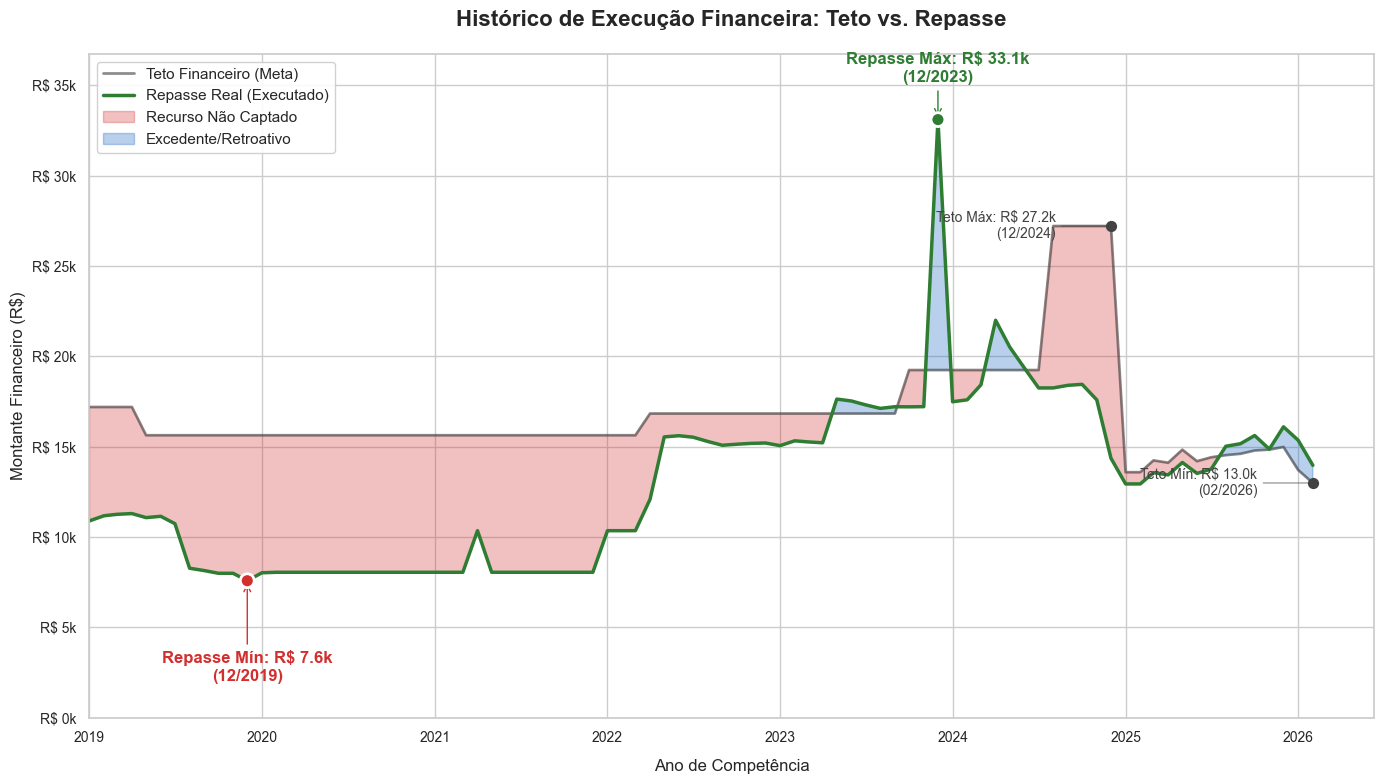

In [4]:
# --- 4. DIAGNÓSTICO FINANCEIRO (EFICIÊNCIA DE CAPTAÇÃO) ---

# 1. Preparação dos KPIs Acumulados
total_teto = df_analise['TETO_POTENCIAL'].sum()
total_repasse = df_analise['REPASSE_REAL'].sum()
total_nao_captado = df_analise['NAO_CAPTADO'].sum()
eficiencia_global = (total_repasse / total_teto) * 100

print(f"💰 RESUMO EXECUTIVO (2019-2025):")
print(f"   🔹 Teto Potencial:      R$ {total_teto:,.2f}")
print(f"   🔸 Repasse Real:        R$ {total_repasse:,.2f}")
print(f"   ⚠️ Recurso Não Captado: R$ {total_nao_captado:,.2f}")
print(f"   📈 Eficiência Média:    {eficiencia_global:.1f}%")
print("-" * 50)

# 2. Funções Auxiliares (Para evitar Lambdas)
def formatar_moeda_k(val):
    """Formata valor para texto curto (Ex: R$ 14.5k)"""
    return f"R$ {val/1000:.1f}k"

def formatar_eixo_y(x, pos):
    """Função de formatação para o Eixo Y do Matplotlib"""
    return f'R$ {x/1000:.0f}k'

def obter_extremo(series, metodo='max'):
    """Retorna a linha do DataFrame com o valor extremo (máximo ou mínimo)"""
    val_extremo = series.max() if metodo == 'max' else series[series > 0].min()
    # Pega o último registro caso haja empate (iloc[-1])
    return df_analise[series == val_extremo].iloc[-1]

# 3. Plotagem do Gráfico
fig, ax = plt.subplots(figsize=(14, 8))

datas = df_analise['DATA_ISO']
y_teto = df_analise['TETO_POTENCIAL']
y_repasse = df_analise['REPASSE_REAL']

# A. Linhas Principais
sns.lineplot(x=datas, y=y_teto, color=CORES['Teto'], label='Teto Financeiro (Meta)', linewidth=2, alpha=0.6, ax=ax)
sns.lineplot(x=datas, y=y_repasse, color=CORES['Repasse'], label='Repasse Real (Executado)', linewidth=2.5, ax=ax)

# B. Áreas de Preenchimento
ax.fill_between(datas, y_teto, y_repasse, where=(y_teto > y_repasse), 
                interpolate=True, color=CORES['Perda'], alpha=0.3, label='Recurso Não Captado')
ax.fill_between(datas, y_teto, y_repasse, where=(y_repasse > y_teto), 
                interpolate=True, color=CORES['Excedente'], alpha=0.3, label='Excedente/Retroativo')

# --- LOGICA DE PONTOS EXTREMOS ---
repasse_max = obter_extremo(df_analise['REPASSE_REAL'], 'max')
repasse_min = obter_extremo(df_analise['REPASSE_REAL'], 'min')
teto_max = obter_extremo(df_analise['TETO_POTENCIAL'], 'max')
teto_min = obter_extremo(df_analise['TETO_POTENCIAL'], 'min')

# 1. TETO (Marcadores Discretos)
ax.scatter([teto_max['DATA_ISO'], teto_min['DATA_ISO']], 
           [teto_max['TETO_POTENCIAL'], teto_min['TETO_POTENCIAL']], 
           color=CORES['Teto'], s=50, zorder=4)

# Texto Teto Máx
ax.annotate(f"Teto Máx: {formatar_moeda_k(teto_max['TETO_POTENCIAL'])}\n({teto_max['PERIODO']})", 
            xy=(teto_max['DATA_ISO'], teto_max['TETO_POTENCIAL']), xytext=(-40, 0),
            textcoords='offset points', ha='right', va='center', color=CORES['Teto'], fontsize=10,
            arrowprops=dict(arrowstyle='-', color=CORES['Teto'], alpha=0.5))

# Texto Teto Mín
ax.annotate(f"Teto Mín: {formatar_moeda_k(teto_min['TETO_POTENCIAL'])}\n({teto_min['PERIODO']})", 
            xy=(teto_min['DATA_ISO'], teto_min['TETO_POTENCIAL']), xytext=(-40, 0),
            textcoords='offset points', ha='right', va='center', color=CORES['Teto'], fontsize=10,
            arrowprops=dict(arrowstyle='-', color=CORES['Teto'], alpha=0.5))

# 2. REPASSE (Marcadores em Destaque)
ax.scatter([repasse_max['DATA_ISO'], repasse_min['DATA_ISO']], 
           [repasse_max['REPASSE_REAL'], repasse_min['REPASSE_REAL']], 
           color=[CORES['Repasse'], CORES['Perda']], s=100, zorder=5, edgecolor='white', linewidth=2)

# Texto Repasse Máx
ax.annotate(f"Repasse Máx: {formatar_moeda_k(repasse_max['REPASSE_REAL'])}\n({repasse_max['PERIODO']})", 
            xy=(repasse_max['DATA_ISO'], repasse_max['REPASSE_REAL']), xytext=(0, 25),
            textcoords='offset points', ha='center', va='bottom', color=CORES['Repasse'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color=CORES['Repasse']))

# Texto Repasse Mín
ax.annotate(f"Repasse Mín: {formatar_moeda_k(repasse_min['REPASSE_REAL'])}\n({repasse_min['PERIODO']})", 
            xy=(repasse_min['DATA_ISO'], repasse_min['REPASSE_REAL']), xytext=(0, -50),
            textcoords='offset points', ha='center', va='top', color=CORES['Perda'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color=CORES['Perda']))

# C. Ajustes Finais
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_eixo_y))

# --- CORREÇÃO DO EIXO X (Híbrida) ---
# Trava o início em 2019, mas deixa o final livre para respiro após 2025
ax.set_xlim(left=datas.min()) 
# ax.set_xlim(datas.min(), datas.max()) <--- REMOVIDA A VERSÃO ANTIGA QUE TRAVAVA TUDO

ax.set_ylim(bottom=0, top=y_teto.max() * 1.35)

ax.set_title('Histórico de Execução Financeira: Teto vs. Repasse', fontsize=16, pad=20)
ax.set_ylabel('Montante Financeiro (R$)')
ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

# EIXO X (Ano)
ax.set_xlabel('Ano de Competência', fontsize=12, labelpad=10)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 📉 Análise de Integridade Financeira

O gráfico acima evidencia a correlação direta entre a qualidade da gestão (IGD-M) e a saúde do caixa municipal.

**Pontos de Atenção:**
1.  **A "Barriga" de Perda (Área Vermelha):** Observa-se que, quando a linha de repasse (verde) se descola da linha de teto (cinza), cria-se uma "zona de ineficiência". Isso ocorre tipicamente quando as taxas de atualização cadastral ou acompanhamento de saúde caem abaixo das metas mínimas, acionando o fator de desconto do Governo Federal.
2.  **Momentos de Superação (Área Azul):** Em contrapartida, os picos onde o repasse supera o teto indicam o recebimento de **valores retroativos**. Isso geralmente acontece após o município corrigir falhas de meses anteriores e conseguir destravar recursos represados, demonstrando capacidade de reação administrativa.
3.  **Tendência Recente:** O comportamento da curva no final de 2025 sugere uma estabilização, mas a margem estreita entre o Teto e o Repasse indica que o município opera no limite, sem "gordura" para erros operacionais.

---

### 5️⃣ Performance dos Indicadores (O "Como")

Enquanto o gráfico financeiro mostra o resultado, este gráfico revela a **causa**. O Índice de Gestão Descentralizada (IGD-M) é composto pela média aritmética de três fatores.

**Período Analisado:** Janeiro/2019 a Novembro/2025.

Analisamos aqui a evolução histórica de cada pilar para identificar qual setor está "puxando a nota para baixo":
* 🔵 **Saúde (`TAXA_ACOMP_SAUDE`):** % de beneficiários com agenda de saúde em dia.
* 🟠 **Educação (`TAXA_FREQ_ESCOLAR`):** % de crianças/jovens com frequência escolar informada.
* 🟣 **Atualização Cadastral (`TAXA_ATUALIZACAO`):** % de famílias com cadastro válido (atualizado dentro do prazo regulamentar de 24 meses).

> **Nota Técnica:** Quedas bruscas na linha de **Educação** geralmente correspondem a períodos de férias escolares ou atraso no sistema de lançamento (presença nula), e não necessariamente abandono escolar.

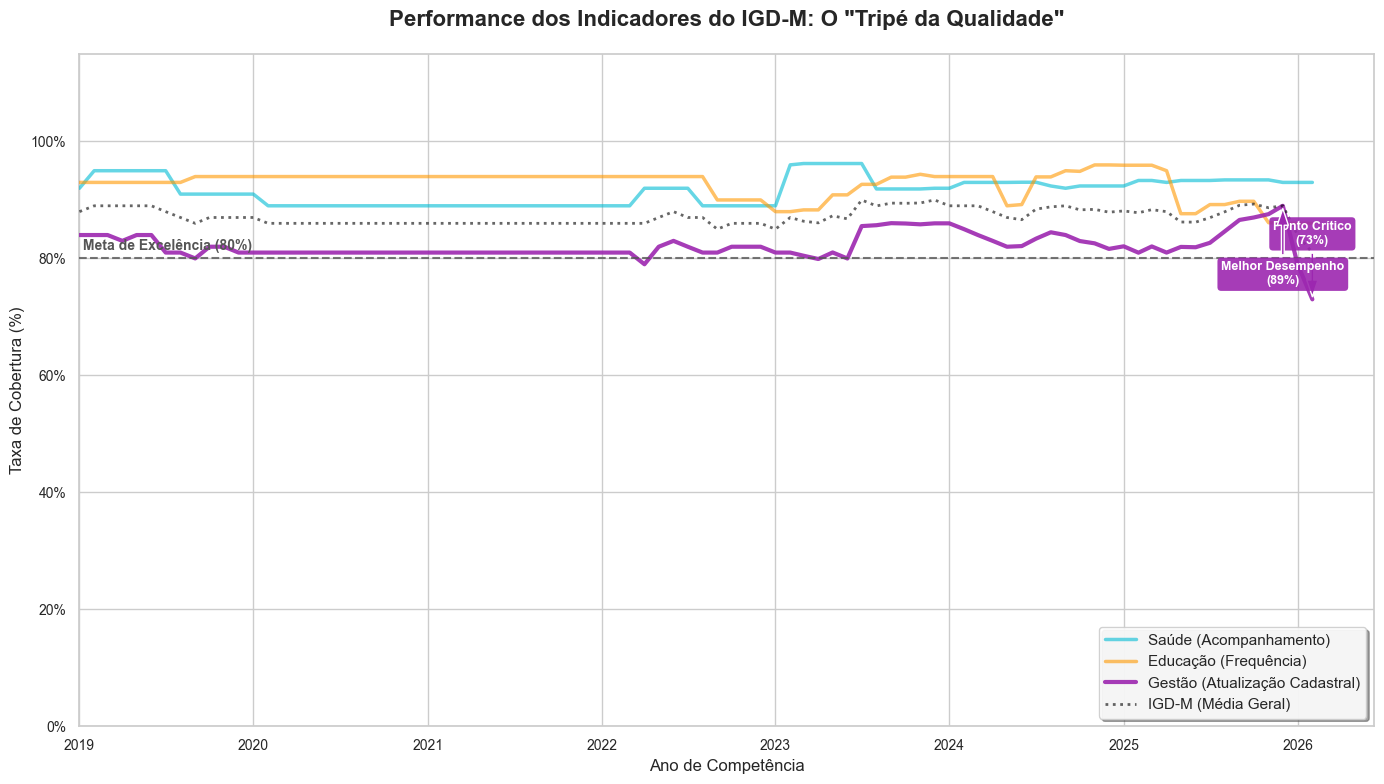

In [5]:
# --- 5. PERFORMANCE DOS INDICADORES (TRIPÉ DA QUALIDADE) ---

# 1. Preparação dos Dados
df_plot = df_analise.copy()
cols_indicadores = ['TAXA_ACOMP_SAUDE', 'TAXA_FREQ_ESCOLAR', 'TAXA_ATUALIZACAO', 'TAXA_IGDM']

# Ajuste de escala (0-1 -> 0-100)
if df_plot['TAXA_IGDM'].max() <= 1.05:
    for col in cols_indicadores:
        df_plot[col] = df_plot[col] * 100

# 2. Configuração do Gráfico
fig, ax = plt.subplots(figsize=(14, 8))
datas = df_plot['DATA_ISO']

# 3. Linha de Referência (Meta de Excelência)
ax.axhline(y=80, color='#555555', linestyle='--', linewidth=1.5, alpha=0.8, zorder=5)
# Texto da meta posicionado no início exato dos dados
ax.text(datas.min(), 81, ' Meta de Excelência (80%)', color='#555555', fontsize=10, fontweight='bold', va='bottom', zorder=6)

# 4. Plotagem das Linhas de Dados

# A. Os 3 Pilares
sns.lineplot(x=datas, y=df_plot['TAXA_ACOMP_SAUDE'], color=CORES['Saude'], 
             label='Saúde (Acompanhamento)', linewidth=2.5, alpha=0.6, ax=ax, zorder=3)

sns.lineplot(x=datas, y=df_plot['TAXA_FREQ_ESCOLAR'], color=CORES['Educacao'], 
             label='Educação (Frequência)', linewidth=2.5, alpha=0.6, ax=ax, zorder=3)

# Destaque para a Gestão (Linha grossa)
sns.lineplot(x=datas, y=df_plot['TAXA_ATUALIZACAO'], color=CORES['Social'], 
             label='Gestão (Atualização Cadastral)', linewidth=3, alpha=0.9, ax=ax, zorder=4)

# B. A Média Geral (IGD-M)
sns.lineplot(x=datas, y=df_plot['TAXA_IGDM'], color='black', 
             label='IGD-M (Média Geral)', linewidth=2, linestyle=':', alpha=0.6, ax=ax, zorder=4)

# --- ANOTAÇÕES DE EXTREMOS (GESTÃO) ---

def obter_extremo(series, metodo='max'):
    val = series.max() if metodo == 'max' else series[series > 0].min()
    return df_plot[series == val].iloc[0]

pior_momento = obter_extremo(df_plot['TAXA_ATUALIZACAO'], 'min')
melhor_momento = obter_extremo(df_plot['TAXA_ATUALIZACAO'], 'max')

bbox_style = dict(boxstyle="round,pad=0.3", fc=CORES['Social'], ec="none", alpha=0.9)
arrow_style = dict(facecolor=CORES['Social'], shrink=0.05, width=2, headwidth=8)

# 1. PIOR MOMENTO (Texto ACIMA)
ax.annotate(f'Ponto Crítico\n({pior_momento["TAXA_ATUALIZACAO"]:.0f}%)', 
            xy=(pior_momento['DATA_ISO'], pior_momento['TAXA_ATUALIZACAO']), 
            xytext=(0, 40), 
            textcoords='offset points', ha='center',
            arrowprops=arrow_style,
            color='white', fontweight='bold', fontsize=9, bbox=bbox_style, zorder=10)

# 2. MELHOR MOMENTO (Texto ABAIXO)
ax.annotate(f'Melhor Desempenho\n({melhor_momento["TAXA_ATUALIZACAO"]:.0f}%)', 
            xy=(melhor_momento['DATA_ISO'], melhor_momento['TAXA_ATUALIZACAO']), 
            xytext=(0, -40), 
            textcoords='offset points', ha='center', va='top',
            arrowprops=arrow_style,
            color='white', fontweight='bold', fontsize=9, bbox=bbox_style, zorder=10)

# -------------------------------------

# 6. Ajustes Finais
def formatar_porcentagem(x, pos): return f'{x:.0f}%'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_porcentagem))

ax.set_title('Performance dos Indicadores do IGD-M: O "Tripé da Qualidade"', fontsize=16, pad=20)
ax.set_ylabel('Taxa de Cobertura (%)')
ax.set_ylim(0, 115) 

# --- CORREÇÃO DO EIXO X (Híbrida) ---
# Trava o início em 2019 (remove espaço branco à esquerda)
# Deixa o final livre (Matplotlib ajusta margem à direita para 2026)
ax.set_xlim(left=datas.min())

# Legenda
ax.legend(loc='lower right', ncol=1, frameon=True, facecolor='white', framealpha=0.9, shadow=True)

# Eixo X
ax.set_xlabel('Ano de Competência', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 📉 Diagnóstico de Risco: Operação na "Zona de Perigo"

A análise visual acima revela um padrão de gestão de **Alta Sensibilidade**. Destaca-se o comportamento da **Taxa de Atualização Cadastral (Linha Roxa)**, que frequentemente oscila perigosamente próxima ao patamar de **80%** (limite crítico para a composição do repasse integral).

**Insights do Gráfico:**
1.  **Margem de Segurança Mínima (2019-2021):** O município operou por longos períodos em um "platô" de ~81%. Embora tecnicamente acima da meta, essa margem exígua de 1% deixava a receita vulnerável a qualquer oscilação operacional.
2.  **Padrão "Dente de Serra" (Pós-2022):** Observam-se quedas agudas seguidas de recuperações verticais. Isso sugere uma **Gestão Reativa**: a mobilização para atualização cadastral parece ocorrer via "mutirões" (quando a nota cai) e não através de um fluxo contínuo de manutenção preventiva.

---

### 6️⃣ Mapeamento de Gaps Operacionais (O "Onde")

Nesta etapa, investigamos o **Gargalo de Capacidade**. Confrontamos o universo de beneficiários que *deveriam* ser acompanhados (demanda estimada) contra os que efetivamente *foram* acompanhados (oferta de serviço).

Focaremos no indicador de **Saúde**, pois ele exige ação física (pesar e medir crianças nas UBSs) e frequentemente representa o maior desafio logístico para o município.

**Conceitos Visuais:**
* **Linha Tracejada (Meta/Demanda):** Total de pessoas perfiladas para acompanhamento de saúde (Crianças < 7 anos, Gestantes), baseada na folha de pagamento do mês anterior.
* **Linha Sólida (Realizado):** Total de pessoas efetivamente pesadas/medidas que tiveram seus dados lançados no sistema.
* **Área Sombreada (Delta Operacional):**
    * **Quando Meta > Realizado:** Representa o **Gap/Déficit** (Pessoas que deixaram de ser acompanhadas).
    * **Quando Realizado > Meta:** Representa **Superávit/Eficiência** (Equipe realizou Busca Ativa e atendeu beneficiários que ainda não constavam na listagem oficial ou recém-cadastrados).

🏥 DIAGNÓSTICO DE CAPACIDADE (SAÚDE - Validado):
   🔹 Público Médio Estimado:  4.992 pessoas
   ⚠️ Déficit Médio Histórico: 355 pessoas não acompanhadas
   📊 Cenário Atual (Nov/25):  De 5.929 esperados, apenas 5.495 foram acompanhados.
   📉 Gap Atual:               434 pessoas (7.1% de perda)
--------------------------------------------------


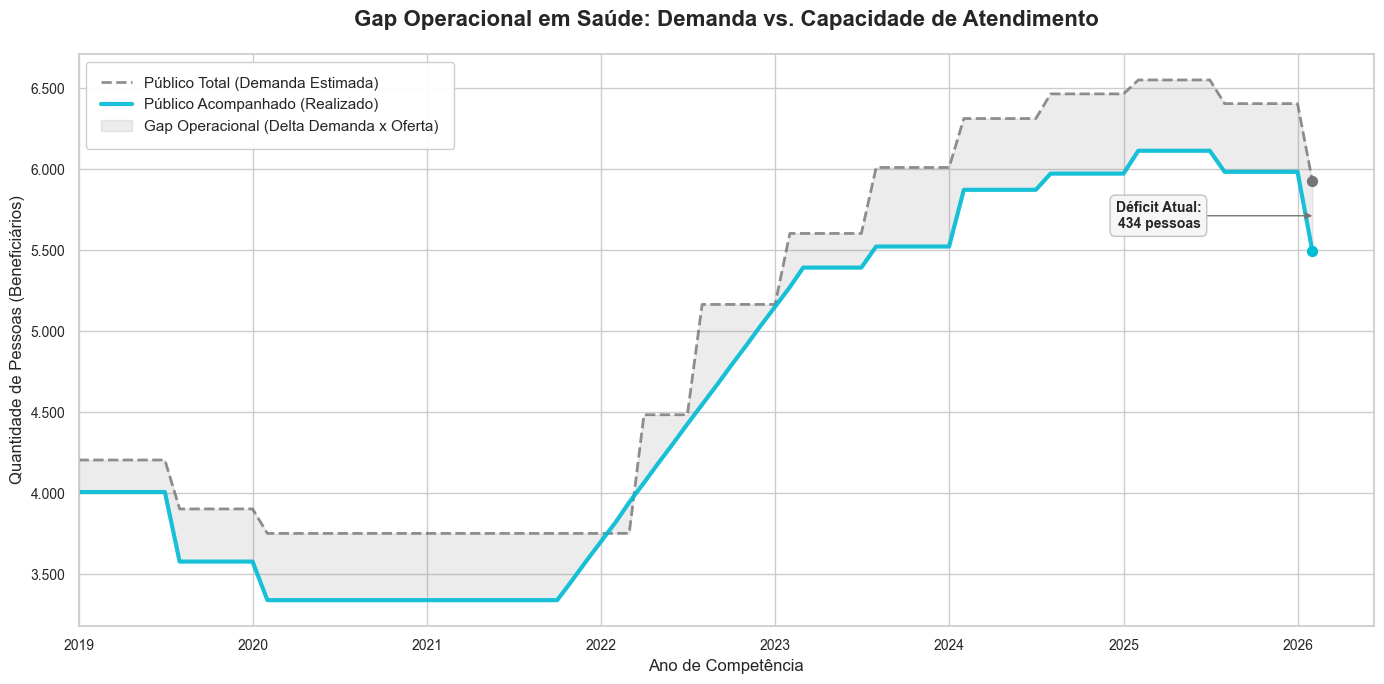

In [6]:
# --- 6. MAPEAMENTO DE GAPS (CAPACIDADE OPERACIONAL - SAÚDE) ---

# 1. Preparação dos Dados
# Filtra apenas colunas de contagem física (Pessoas)
cols_gap = ['DATA_ISO', 'SAUDE_PUBLICO_TOTAL', 'SAUDE_ACOMPANHADOS', 'PERIODO']
df_gap = df_analise[cols_gap].copy()

# --- CORREÇÃO DE BURACOS ---
# Preenche falhas (NaNs) com interpolação linear para garantir continuidade visual
df_gap['SAUDE_PUBLICO_TOTAL'] = df_gap['SAUDE_PUBLICO_TOTAL'].interpolate(method='linear', limit_direction='both')
df_gap['SAUDE_ACOMPANHADOS'] = df_gap['SAUDE_ACOMPANHADOS'].interpolate(method='linear', limit_direction='both')

# Cria a coluna de Déficit (Gap Absoluto) APÓS tratar os dados
df_gap['GAP_ABSOLUTO'] = df_gap['SAUDE_PUBLICO_TOTAL'] - df_gap['SAUDE_ACOMPANHADOS']

# Calcula médias para insights
media_publico = df_gap['SAUDE_PUBLICO_TOTAL'].mean()
media_gap = df_gap['GAP_ABSOLUTO'].mean()
pct_gap_medio = (media_gap / media_publico) * 100
ultimo = df_gap.iloc[-1] # Pega o dado mais recente

# Função auxiliar para formatação brasileira
def fmt_br(valor):
    return f"{int(valor):_}".replace('_', '.')

print(f"🏥 DIAGNÓSTICO DE CAPACIDADE (SAÚDE - Validado):")
print(f"   🔹 Público Médio Estimado:  {fmt_br(media_publico)} pessoas")
print(f"   ⚠️ Déficit Médio Histórico: {fmt_br(media_gap)} pessoas não acompanhadas")
print(f"   📊 Cenário Atual (Nov/25):  De {fmt_br(ultimo['SAUDE_PUBLICO_TOTAL'])} esperados, apenas {fmt_br(ultimo['SAUDE_ACOMPANHADOS'])} foram acompanhados.")
print(f"   📉 Gap Atual:               {fmt_br(ultimo['GAP_ABSOLUTO'])} pessoas ({pct_gap_medio:.1f}% de perda)")
print("-" * 50)

# 2. Configuração do Gráfico
fig, ax = plt.subplots(figsize=(14, 7))
datas = df_gap['DATA_ISO']

y_total = df_gap['SAUDE_PUBLICO_TOTAL']
y_real = df_gap['SAUDE_ACOMPANHADOS']

# 3. Plotagem

# A. Universo (Demanda)
sns.lineplot(x=datas, y=y_total, color='#757575', linestyle='--', linewidth=2, 
             label='Público Total (Demanda Estimada)', alpha=0.8, ax=ax)

# B. Realizado (Oferta)
sns.lineplot(x=datas, y=y_real, color=CORES['Saude'], linewidth=3, 
             label='Público Acompanhado (Realizado)', alpha=0.9, ax=ax)

# C. O GAP (Área de Oportunidade)
ax.fill_between(datas, y_total, y_real, 
                interpolate=True, color='gray', alpha=0.15, 
                label='Gap Operacional (Delta Demanda x Oferta)')

# 4. Destaque do Último Cenário
gap_atual = ultimo['GAP_ABSOLUTO']

# Marcadores no último mês
ax.scatter(ultimo['DATA_ISO'], ultimo['SAUDE_PUBLICO_TOTAL'], color='#757575', s=50, zorder=5)
ax.scatter(ultimo['DATA_ISO'], ultimo['SAUDE_ACOMPANHADOS'], color=CORES['Saude'], s=50, zorder=5)

# Anotação de Conclusão
ax.annotate(f"Déficit Atual:\n{fmt_br(gap_atual)} pessoas", 
            xy=(ultimo['DATA_ISO'], (ultimo['SAUDE_PUBLICO_TOTAL'] + ultimo['SAUDE_ACOMPANHADOS'])/2),
            xytext=(-80, 0), textcoords='offset points',
            ha='right', va='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4", fc="#f5f5f5", ec="#bdbdbd", alpha=0.9),
            arrowprops=dict(arrowstyle='-|>', color='#757575', shrinkA=0, shrinkB=0))

# 5. Ajustes Finais
ax.set_title('Gap Operacional em Saúde: Demanda vs. Capacidade de Atendimento', fontsize=16, pad=20)
ax.set_ylabel('Quantidade de Pessoas (Beneficiários)')
ax.set_xlabel('Ano de Competência')

# --- CORREÇÃO HÍBRIDA DO EIXO X (IGUAL AO ANTERIOR) ---
# Trava o início onde há dados reais, mas deixa o final livre para respiro
data_inicio = df_gap.dropna(subset=['SAUDE_PUBLICO_TOTAL'])['DATA_ISO'].min()
ax.set_xlim(left=data_inicio) 

# Legenda Reposicionada
ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.95, borderpad=1)

# Eixo Y com Ponto no Milhar
import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: fmt_br(x)))

# Eixo X
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 📉 Análise de Padrão: O Efeito "Escada"

A visualização acima revela um comportamento operacional distinto, caracterizado pela formação de **degraus (platôs)** na linha de demanda (tracejada) e na linha de atendimento (sólida).

**Interpretação do Fenômeno:**
1.  **Crescimento em Lotes:** A demanda não sobe linearmente; ela salta. Isso reflete a dinâmica de **inclusão de novas folhas de pagamento** pelo Governo Federal ou grandes ações de cadastramento municipal, que inserem centenas de famílias no sistema de uma só vez.
2.  **Acomodação Operacional:** Logo após um "salto" na demanda (degrau sobe), observa-se que a linha de atendimento (azul) leva um tempo para reagir e alcançar o novo patamar.
3.  **Zona de Estresse:** O "Gap" (área cinza) tende a abrir justamente nesses momentos de salto, indicando que a capacidade da equipe de saúde é **elástica, mas tem delay**. A equipe consegue crescer, mas demora alguns meses para absorver o novo contingente de beneficiários.

---

### 7️⃣ Drivers Financeiros (Ranking de Impacto)

Em vez de uma matriz complexa, utilizamos aqui um **Ranking de Correlação** para isolar os fatores que impulsionam a receita do município. Este gráfico responde matematicamente à pergunta: *"Onde devo alocar minha equipe para aumentar a arrecadação?"*

**Como ler este gráfico:**
* **Barras à Direita (Verdes/Positivas):** Indicadores que, quando sobem, fazem o dinheiro aumentar. O tamanho da barra indica a força desse impacto.
* **Barras à Esquerda (Vermelhas/Negativas):** Fatores que jogam contra o repasse.
* **Próximo de Zero:** Indicadores com pouca influência no resultado final.

**Destaque da Variável "Volume de Famílias":**
Representa a base total de beneficiários (demanda) no Cadastro Único.
* **Se a barra for Verde:** Indica **Escalabilidade**. O município consegue absorver o aumento da demanda (novas famílias de baixa renda/vulnerabilidade) e converter isso em mais repasse, mantendo a eficiência.
* **Se a barra for Vermelha:** Indica **Gargalo**. O aumento de famílias "entope" o sistema, derruba os índices de qualidade e reduz o repasse final.

**Objetivo:** Definir prioridades de gestão. Se o "Cadastro" tiver a barra maior que a "Saúde", a equipe deve priorizar a atualização cadastral para maximizar o retorno a curto prazo.

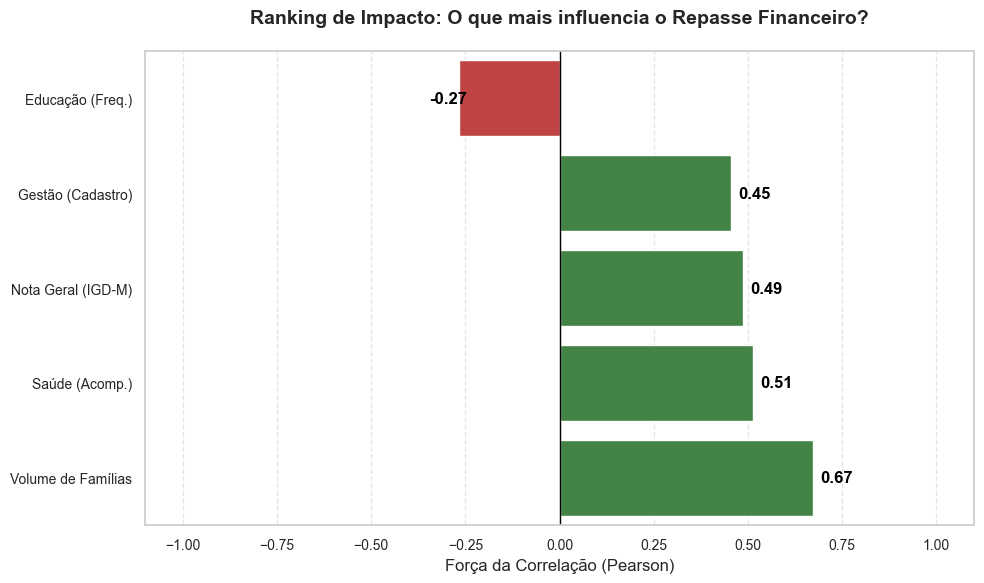

--------------------------------------------------
📊 CONCLUSÃO DA ANÁLISE:
   O indicador com maior peso sobre o dinheiro é: VOLUME DE FAMÍLIAS
   Tipo de impacto: POSITIVO
--------------------------------------------------


In [7]:
# --- 7. RANKING DE IMPACTO FINANCEIRO ---

# 1. Preparação dos Dados
cols_analise = [
    'REPASSE_REAL', 
    'TAXA_IGDM', 
    'TAXA_ACOMP_SAUDE', 
    'TAXA_FREQ_ESCOLAR', 
    'TAXA_ATUALIZACAO', 
    'QTD_FAMILIAS'
]

# Cria subset e trata dados
df_rank = df_analise[cols_analise].apply(pd.to_numeric, errors='coerce').copy()
df_rank = df_rank.interpolate(method='linear', limit_direction='both')

# Renomeia para exibição
labels_rank = {
    'REPASSE_REAL': 'Repasse ($)',
    'TAXA_IGDM': 'Nota Geral (IGD-M)',
    'TAXA_ACOMP_SAUDE': 'Saúde (Acomp.)',
    'TAXA_FREQ_ESCOLAR': 'Educação (Freq.)',
    'TAXA_ATUALIZACAO': 'Gestão (Cadastro)',
    'QTD_FAMILIAS': 'Volume de Famílias'
}
df_rank = df_rank.rename(columns=labels_rank)

# 2. Cálculo das Correlações (Focadas apenas no Repasse)
# Calculamos a correlação de TODAS as colunas contra a coluna 'Repasse ($)'
correlacoes = df_rank.corrwith(df_rank['Repasse ($)']).drop('Repasse ($)')
correlacoes = correlacoes.sort_values(ascending=True) # Ordena do negativo para positivo

# 3. Definição de Cores (Verde para Positivo, Vermelho para Negativo)
cores = ['#d32f2f' if x < 0 else '#388e3c' for x in correlacoes.values]

# 4. Plotagem
plt.figure(figsize=(10, 6))

# Cria o gráfico de barras horizontais
ax = sns.barplot(x=correlacoes.values, y=correlacoes.index, palette=cores)

# Adiciona os valores nas pontas das barras
for i, v in enumerate(correlacoes.values):
    offset = 0.02 if v >= 0 else -0.08 # Ajuste fino da posição do texto
    ax.text(v + offset, i, f"{v:.2f}", va='center', fontweight='bold', color='black')

# Linha central (Eixo Zero)
ax.axvline(0, color='black', linewidth=1)

# Ajustes Finais
plt.title('Ranking de Impacto: O que mais influencia o Repasse Financeiro?', fontsize=14, pad=20)
plt.xlabel('Força da Correlação (Pearson)', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(-1.1, 1.1) # Garante espaço para os rótulos

plt.tight_layout()
plt.show()

# Insight Textual
maior_impacto = correlacoes.abs().idxmax()
direcao = "POSITIVO" if correlacoes[maior_impacto] > 0 else "NEGATIVO"

print("-" * 50)
print(f"📊 CONCLUSÃO DA ANÁLISE:")
print(f"   O indicador com maior peso sobre o dinheiro é: {maior_impacto.upper()}")
print(f"   Tipo de impacto: {direcao}")
print("-" * 50)

---

### 8️⃣ Conclusão do Diagnóstico e Próximos Passos

Consolidamos aqui os achados estatísticos deste notebook. Este resumo serve como base para a proposta de intervenção (Plano de Ação) que será desenhada na próxima fase do projeto.

**Resumo dos Achados:**
1.  **Financeiro:** Identificamos o montante exato de recursos perdidos (Custo de Oportunidade).
2.  **Operacional:** Mapeamos o tamanho da "fila oculta" na Saúde.
3.  **Estratégico:** Definimos estatisticamente qual indicador é a alavanca principal para recuperação de receita.

In [9]:
# --- 8. RELATÓRIO EXECUTIVO FINAL (CONSOLIDAÇÃO) ---
# Recalculamos as métricas aqui para garantir que a célula funcione de forma independente

# A. Recálculos Financeiros (Baseados no df_analise)
total_teto = df_analise['TETO_POTENCIAL'].sum()
total_repasse = df_analise['REPASSE_REAL'].sum()
total_nao_captado = total_teto - total_repasse
eficiencia_media = (total_repasse / total_teto) * 100

# B. Recálculos Operacionais (Baseados no último dado disponível)
# Garante que temos dados numéricos para a conta
gap_series = df_analise['SAUDE_PUBLICO_TOTAL'] - df_analise['SAUDE_ACOMPANHADOS']
gap_atual = gap_series.iloc[-1]   # Último mês
media_gap = gap_series.mean()     # Média histórica

print("="*60)
print(f"📋 RELATÓRIO DE DIAGNÓSTICO MUNICIPAL (2019-2026)")
print("="*60)

# 1. O Problema (Financeiro)
print(f"\n💰 1. IMPACTO FINANCEIRO:")
# Formatação brasileira manual para garantir visualização correta
val_fmt = f"{total_nao_captado:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
print(f"   O município deixou de captar: R$ {val_fmt}")
print(f"   Eficiência média da gestão:   {eficiencia_media:.1f}%")

# 2. A Causa (Operacional)
print(f"\n⚙️ 2. GARGALO OPERACIONAL (SAÚDE):")
print(f"   Déficit atual de cobertura:   {int(gap_atual)} pessoas")
print(f"   Média de perda histórica:     {int(media_gap)} pessoas/semestre")

# 3. A Solução (Estratégia)
# Tenta pegar a variável da etapa anterior. Se não existir, avisa.
try:
    print(f"\n🎯 3. DIRECIONADOR ESTRATÉGICO:")
    print(f"   Fator de maior impacto:       {maior_impacto.upper()}")
    tipo_impacto = "POSITIVO (Alavanca de Receita)" if direcao == "POSITIVO" else "NEGATIVO (Dreno de Receita)"
    print(f"   Natureza do impacto:          {tipo_impacto}")
except NameError:
    print("   ⚠️ Execute a Etapa 7 para ver o direcionador estratégico.")

print("-" * 60)


📋 RELATÓRIO DE DIAGNÓSTICO MUNICIPAL (2019-2026)

💰 1. IMPACTO FINANCEIRO:
   O município deixou de captar: R$ 331.691,35
   Eficiência média da gestão:   77.1%

⚙️ 2. GARGALO OPERACIONAL (SAÚDE):
   Déficit atual de cobertura:   434 pessoas
   Média de perda histórica:     390 pessoas/semestre

🎯 3. DIRECIONADOR ESTRATÉGICO:
   Fator de maior impacto:       VOLUME DE FAMÍLIAS
   Natureza do impacto:          POSITIVO (Alavanca de Receita)
------------------------------------------------------------


---

### 🧠 Análise Crítica: O "Salto" de Receita (2023-2024)

Ao observar o gráfico financeiro, nota-se uma desconexão aparente: a curva de receita (verde) cresce muito mais rápido que a curva de eficiência (que já era estável).

**Fatores Contextuais (Causa Raiz da Explosão de Receita):**
1.  **Fator Exógeno (Governo Federal):** A transição do programa *Auxílio Brasil* para o *Novo Bolsa Família* e a implementação do **PROCAD-SUAS** em 2023 injetaram recursos extraordinários no sistema, aumentando o valor *per capita* repassado aos municípios.
2.  **Fator Endógeno (Gestão Municipal):** A gestão eficiente do município funcionou como a **chave de acesso**. O dinheiro estava disponível em Brasília, mas só entrou no cofre da prefeitura porque o município manteve seus índices (IGD-M) altos.

**Conclusão:** O município surfou a "onda de valorização" do programa federal porque estava com a "prancha" (IGD-M) bem posicionada. Se a nota tivesse caído nesse período, o prejuízo financeiro teria sido milionário (perda de oportunidade).

---

### 🧠 Diagnóstico de Inteligência: Assimetria entre Serviços

A sobreposição das curvas no gráfico acima revela comportamentos distintos entre os setores, permitindo conclusões estratégicas:

**1. Educação (Linha Estável):**
Historicamente a mais resiliente. Isso sugere que o fluxo de dados entre escolas e CRAS está maduro. É o "pilar de sustentação" da nota do município.

**2. Saúde (Linha Volátil):**
Apresenta alta sensibilidade. Quedas bruscas seguidas de recuperações rápidas indicam que o setor funciona na base de "campanhas" (ex: mutirões de pesagem) e não em fluxo contínuo. É onde reside o maior risco operacional de curto prazo.

**3. Gestão/Cadastro (O Gargalo Estrutural):**
A Taxa de Atualização Cadastral frequentemente opera perigosamente próxima ao limite de 80%.
* **O Risco Invisível:** Existe um *gap* entre a eficiência da escola e a do cadastro. A família manda o filho para a escola (cumpre a condicionalidade), mas esquece de atualizar o cadastro no CRAS.
* **Consequência:** Risco de bloqueio do benefício por desatualização cadastral, mesmo com a criança frequentando a aula.

**📌 Recomendação:** Utilizar a capilaridade das escolas (onde o público está presente) para convocar ativamente as famílias para a atualização cadastral, transformando a eficiência da Educação em alavanca para o Cadastro.

---
**🚀 Próximo Passo:** Executar o **Notebook 03 (Simulação de Cenários & Plano de Ação)** para projetar o retorno financeiro (ROI) de melhorias operacionais e estipular as metas de recuperação para 2026.